In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import datetime
today = datetime.date.today()
import pickle
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)
from flonacomldft.models.mixture import Mixture

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

In [2]:
T = 350
kBT_in_eV = kB * T
kBT_in_eV

0.030160656180260245

In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Paths to the source files

In [11]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/earlier_simulations'

os.listdir(subproject_path)

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']
adaptive_dft_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

process_ids_woNP = [28685740, 28685741]
process_ids_wNP = [28706672, 28707820]

### 0.2 - Loading models

In [32]:
def load_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    f = 'results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id, isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    
    models = []
    for dic in dic_trainings['dict_flows_training']: ## looping over all the training slices -- 31 in total
        models += dic[0]['models'] ## 11 models per slice
    return models

In [36]:
isomer_id = 1

# process_id = process_ids_wNP[isomer_id]
# models = load_models(isomer_id, process_id, project_path=subproject_path+'/2-adaptive-mlp/')
# len(models)

process_id = process_ids_woNP[isomer_id]
models = load_models(isomer_id, process_id, project_path=subproject_path+'/1-adaptive/')
len(models)

341

In [51]:
def load_mlp_models(isomer_id, process_id, project_path=subproject_path+ '/2-adaptive-mlp/'):
    f = 'results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id, isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps_training']]
    return mlp_models

In [54]:
isomer_id = 1
process_id = process_ids_wNP[isomer_id]
mlp_models = load_mlp_models(isomer_id, process_id, project_path=subproject_path+'/2-adaptive-mlp/')
len(mlp_models)

31

#### 0.2.z Inspecting the MLP training losses

Number of saved mlps: 31
Number of saved mlps: 31


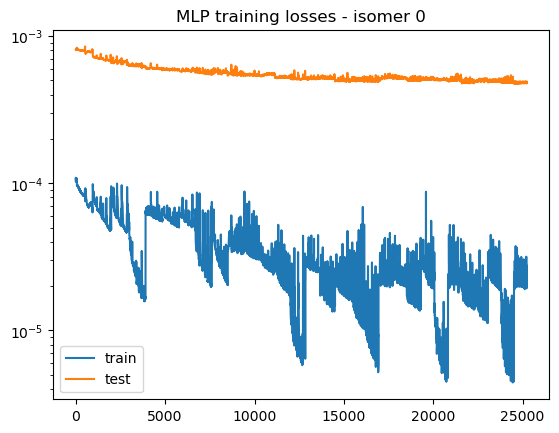

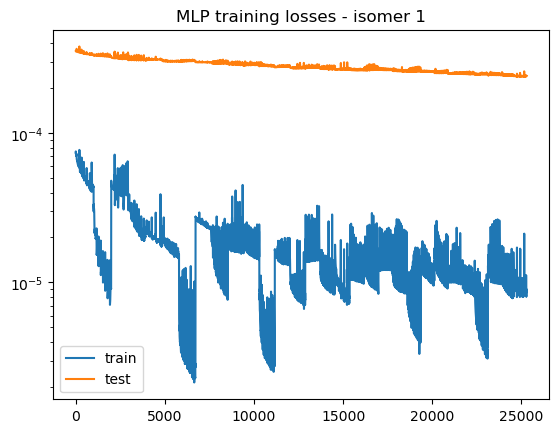

In [123]:
# process_id_mlps 

for isomer_id in mode_labels:
    process_id_mlp = process_id_mlps[isomer_id]

    f = 'results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id_mlp, isomer_id, process_id_mlp)
    dic_trainings = load_pickle_file(f, path=subproject_path + '/2-adaptive-mlp/')
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps_training']]

    print('Number of saved mlps:', len(mlp_models))


    test_losses = []
    train_losses = []
    for train_slice in range(len(dic_trainings['dict_mlps_training'])):
        if train_slice == 0:
            continue
        test_losses += dic_trainings['dict_mlps_training'][train_slice][0]['test_loss']
        train_losses += dic_trainings['dict_mlps_training'][train_slice][0]['train_loss']

    plt.figure()
    plt.title('MLP training losses - isomer {:d}'.format(isomer_id))
    plt.plot(train_losses, label='train')
    plt.plot(test_losses, label='test')
    plt.yscale('log')
    plt.legend()

### 0.3 - Loading the data

In [9]:
# kinds = ['xs_adaptive', 'xs_proposals', 'MD-sampling']

# # def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
# #     torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
# #                   path=project_path)
# #     return torch_tensor[:, :12], torch_tensor[:, 12]

# def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
#     if kind == 'xs_adaptive':
#         torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
#                     path=project_path)
#         xs = torch_tensor[:, :12]
#         us = torch_tensor[:, 12]
#     elif kind == 'MD-sampling':
#         torch_tensor = load_csv_file('is{:d}_samples_rc_md_{:d}.csv'.format(isomer_id, process_id),
#                     path=project_path)
#         xs = torch_tensor[:, :12]
#         us = torch_tensor[:, 12]
#     elif kind == 'xs_proposals':
#         # f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
#         # dic_trainings = load_pickle_file(f, path=project_path)
#         # xs = torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12)
#         # us = torch.stack(dic_trainings['us_proposals']).reshape(-1)
#         torch_tensor = load_csv_file('is{:d}_proposals_xs_{:d}.csv'.format(isomer_id, process_id),
#                     path=project_path)
#         xs = torch_tensor[:, :12]
#         us = torch_tensor[:, 12]

#     return xs, us

## 0.4 - Metropolis-Hastings

In [55]:
"""
Script with Metropolis-Hasting algorithm. 

"""

import time
import numpy as np
import torch
import tqdm

from flonacomldft.collective_variables import get_collective_variables
# from ase.parallel import parprint as print
from ase.units import kB

#TODO: Add calculator for MLP
#TODO: Add cv values to return
#TODO: add docstrings

def run_metropolis(model, 
                    init, 
                    n_chains,
                    n_steps,
                    energy_type,
                    temperature,
                    mixture,
                    mlp_models=None,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=True,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=False,
                    device='cpu',
                    folder_name=None,
                 ):

    assert init.shape[0] == n_chains

    if mixture:
        try:
            assert len(model.models) > 1
        except:
            raise RuntimeError("Model is not a mixture")
    
    print("Running Metropolis-Hastings")

    x_init = init[:, :dim]
    u_init = init[:, dim]
    isomer_init = init[:, dim+1]

    beta = 1 / (kB * temperature)

    print("Number of chains: {:d}".format(n_chains))
    print("Number of steps: {:d}".format(n_steps))
    print("Temperature: {:.1f}K".format(temperature))
    print("Energy Type: {:s}".format(energy_type))

    if "mlp" in energy_type:
        #TODO: Add calculator for MLP
        
        if (mlp_models is None):
            raise RuntimeError("No model to calculate energy")
        
        if mixture:
            print('Mixture model')
            model_mlp_is0, model_mlp_is1 = mlp_models
        else:
            if(isomer_init.sum()==0):
                model_mlp_is0 = mlp_models[0]
            else:
                model_mlp_is1 = mlp_models[0]
        
        print("Use Neural Predictor: True")
    
    else:
        
        print("No Neural Predictor")

    use_calc = False

    if return_ratios:
        ratios = []

    if return_proposals:
        xs_proposals = []
        us_proposals = []
        isomers_proposals = []
        nlls_proposals = []

    print("Mixture Model: {:s}".format(str(mixture)))

    if mixture:
        weights = [model.weights.clone().detach()]

    xs = []
    us = []
    accs = []
    isomers = []
    nlls = []

    time_step_mcmc = []

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
        print("Step \t Acc Rate")

    for dt in pbar:

        if mixture:
            x_new, isomer_new = model.sample(n_chains, return_mus=True)
        else:
            x_new = model.sample(n_chains)
            isomer_new = isomer_init.clone()

        x_new = x_new.clone().detach() #set float
        isomer_new = isomer_new.clone().detach() #set dype
        
        nll_x = model.nll(x_new)
        nll_x_init = model.nll(x_init)

        if return_proposals:
            xs_proposals.append(x_new.clone().detach())
            isomers_proposals.append(isomer_new.clone().detach())
            nlls_proposals.append(nll_x.clone().detach())

        if "mlp" in energy_type:

            u_new = torch.zeros((n_chains, 1)).squeeze()

            if mixture:
                u_new[~isomer_new.bool()] = model_mlp_is0(x_new[~isomer_new.bool()]).reshape(1, -1)
                u_new[isomer_new.bool()] = model_mlp_is1(x_new[isomer_new.bool()]).reshape(1, -1)

            else:
                if(isomer_new.sum()==0):
                    u_new = model_mlp_is0(x_new)
                else:
                    u_new = model_mlp_is1(x_new)

            u_new = u_new.squeeze()

        time_step_mcmc.append(time.time())

        if return_proposals:
            us_proposals.append(u_new.clone().detach())
        
        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)

        if return_ratios:
            ratios.append( torch.min(ratio.clone().detach(), 
                            torch.ones_like(ratio)) )

        s = torch.rand_like(ratio)
        acc = s < torch.min(ratio.detach(), torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        if mixture:
            isomer_new[~acc] = isomer_init[~acc]
        
        else:
            isomer_new = isomer_init.clone()
        
        xs.append(x_new.clone().detach())
        us.append(u_new.clone().detach())
        accs.append(acc.clone().detach())
        isomers.append(isomer_new.clone().detach())
        nlls.append(model.nll(x_new).clone().detach())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description("Step {:d} \t Acceptance Rate {:.3f}".format(
                dt, acc.float().mean().item()))
        else:
            print("{:d} \t {:.3f}".format( dt, 
                                        acc.float().mean().item()
                                        )
            )

        if mixture and update_weights and dt > 0 and dt % scheduler_weights == 0:

            window_weights = torch.stack( [(~torch.stack(isomers).bool())[-scheduler_weights:].float().mean(),
                              torch.stack(isomers)[-scheduler_weights:].float().mean()] )

            new_weights = alpha * model.weights.clone() + (1 - alpha) * window_weights.clone()

            if torch.all(new_weights < 0.75):

                model.weights = new_weights.clone()

            weights.append(model.weights.clone().detach())

    to_return = {
        'xs': torch.stack(xs),
        'us': torch.stack(us),
        'accs': torch.stack(accs),
        'isomers': torch.stack(isomers),
        'nlls': torch.stack(nlls),
        'time_mcmc': time_step_mcmc,
    }

    if return_ratios:
        to_return['ratios'] = torch.stack(ratios)

    if return_proposals:
        to_return['xs_proposals'] = torch.stack(xs_proposals)
        to_return['us_proposals'] = torch.stack(us_proposals)
        to_return['isomers_proposals'] = torch.stack(isomers_proposals)
        to_return['nlls_proposals'] = torch.stack(nlls_proposals)

    if use_calc:
            
        to_return['xs_calc'] = torch.stack(xs_calc)
        to_return['us_calc'] = torch.stack(us_calc)
        to_return['isomers_calc'] = torch.stack(isomers_calc)
        to_return['inds_calc'] = torch.stack(inds_calc)

    if mixture and update_weights:
        to_return['weights'] = torch.stack(weights)

    return to_return


#  2 - Mixture Metropolis-Hastings on mixture using the MLP model trained adaptively

## 2.1 - Adaptive 30% DFT Flows

In [175]:
process_id_mlps = process_ids_wNP
process_id_flows = process_ids_wNP
folder = '/2-adaptive-mlp/'

seed = 0
torch.manual_seed(seed)

flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)

# MH parameters
n_chains = 200
mixture = True
update_weights = False
mixture_weights = torch.tensor([0.75, 0.25])
temperature = 350
energy_type = 'mlp'
n_steps = 10000
mlp_train_slice = 30 # ,0

dic_mcmcs = {}

### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models

### Running the MCMC for the selected training slices
for flow_train_slice in flow_train_slices:
    flow_models = []
    mlp_models = [] ## could do it only once if we are using one mlp
    
    for isomer_id in mode_labels:
        flow_model = flow_models_all['isomer {:d}'.format(isomer_id)][flow_train_slice]
        flow_models.append(flow_model)

        mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
        mlp_models.append(mlp_model)
    
    mixture_model = Mixture(flow_models, init_weights=mixture_weights)
    print('Using relative weights: ', mixture_model.weights)

    init = mixture_model.sample(n_chains)
    init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)

    to_return = run_metropolis(mixture_model, init, n_chains, n_steps, energy_type,
                        temperature,
                        mixture,
                        mlp_models=mlp_models,
                        frac_computed=0.2,
                        dim=12,
                        update_weights=update_weights,
                        scheduler_weights=10,
                        alpha=0.5,
                        return_ratios=True,
                        return_proposals=True,
                        with_tqdm=True,
                        device='cpu',
                        folder_name=None,
                    )

    key = 'flow_train_slice_{:d}_mlp_train_slice_{:d}'.format(flow_train_slice, mlp_train_slice)
    dic_mcmcs[key] = to_return

Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.100: 100%|██████████| 10000/10000 [02:31<00:00, 66.02it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.120: 100%|██████████| 10000/10000 [02:28<00:00, 67.43it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


...

Step 9999 	 Acceptance Rate 0.120: 100%|██████████| 10000/10000 [02:27<00:00, 67.97it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.100: 100%|██████████| 10000/10000 [02:21<00:00, 70.76it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.005: 100%|██████████| 10000/10000 [02:28<00:00, 67.56it/s]


In [176]:
# dic_mcmcs['flow_train_slice_0_mlp_train_slice_30'].keys()
# # save the results
date = str(today)
filename = subproject_path + '/9-mcmc-bar/'+ date + '-ab-flows-mixture-wNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
with open(filename, 'wb') as f:
    pickle.dump(dic_mcmcs, f)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-ab-flows-mixture-wNP-MCMC-outputs-mlpmodel30.pkl


## 2.2 - Adaptive 30% DFT Flows

In [181]:
process_id_mlps = process_ids_wNP
folder_mlp = '/2-adaptive-mlp/'

process_id_flows = process_ids_woNP
folder = '/1-adaptive/'

seed = 0
torch.manual_seed(seed)

flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int) # upo to 341

# MH parameters
n_chains = 200
mixture = True
update_weights = False
mixture_weights = torch.tensor([0.75, 0.25])
temperature = 350
energy_type = 'mlp'
n_steps = 10000
mlp_train_slice = 30 # ,0

dic_mcmcs = {}

### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder_mlp)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models

### Running the MCMC for the selected training slices
for flow_train_slice in flow_train_slices:
    flow_models = []
    mlp_models = [] ## could do it only once if we are using one mlp
    
    for isomer_id in mode_labels:
        flow_model = flow_models_all['isomer {:d}'.format(isomer_id)][flow_train_slice]
        flow_models.append(flow_model)

        mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
        mlp_models.append(mlp_model)
    
    mixture_model = Mixture(flow_models, init_weights=mixture_weights)
    print('Using relative weights: ', mixture_model.weights)

    init = mixture_model.sample(n_chains)
    init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)

    to_return = run_metropolis(mixture_model, init, n_chains, n_steps, energy_type,
                        temperature,
                        mixture,
                        mlp_models=mlp_models,
                        frac_computed=0.2,
                        dim=12,
                        update_weights=update_weights,
                        scheduler_weights=10,
                        alpha=0.5,
                        return_ratios=True,
                        return_proposals=True,
                        with_tqdm=True,
                        device='cpu',
                        folder_name=None,
                    )

    key = 'flow_train_slice_{:d}_mlp_train_slice_{:d}'.format(flow_train_slice, mlp_train_slice)
    dic_mcmcs[key] = to_return

Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.105: 100%|██████████| 10000/10000 [25:33<00:00,  6.52it/s]  


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.115: 100%|██████████| 10000/10000 [02:23<00:00, 69.68it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


...

Step 9999 	 Acceptance Rate 0.170: 100%|██████████| 10000/10000 [02:24<00:00, 69.00it/s]


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.220: 100%|██████████| 10000/10000 [06:33<00:00, 25.42it/s] 


Using relative weights:  tensor([0.7500, 0.2500], requires_grad=True)
Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True


Step 9999 	 Acceptance Rate 0.115: 100%|██████████| 10000/10000 [02:19<00:00, 71.72it/s]


In [182]:
# # save the results
# dic_mcmcs['isomer_1_flow_train_slice_0_mlp_train_slice_30'].keys()
# # save the results
date = str(today)
filename = subproject_path + '/9-mcmc-bar/'+ date + '-ab-flows-mixture-woNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
with open(filename, 'wb') as f:
    pickle.dump(dic_mcmcs, f)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-ab-flows-mixture-woNP-MCMC-outputs-mlpmodel30.pkl


## 2.z - Plotting the results

### 2.z.1 Adaptive 30% DFT flows - "wNP"

Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000


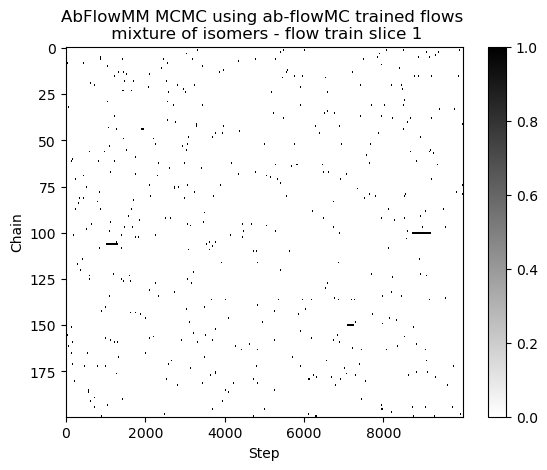

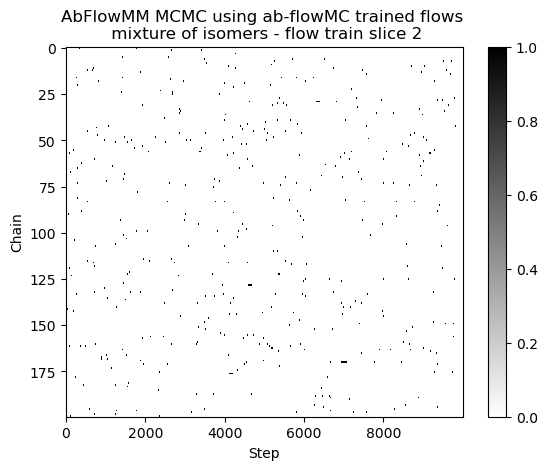

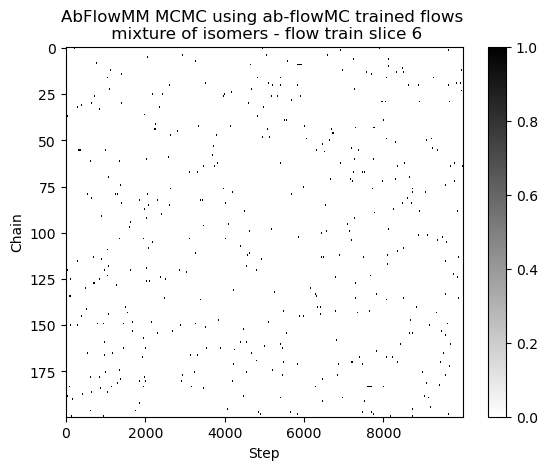

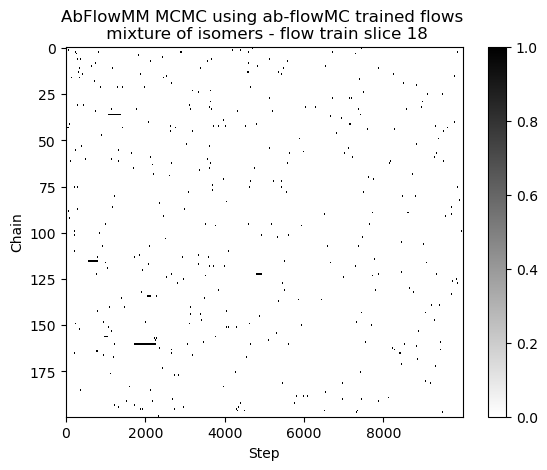

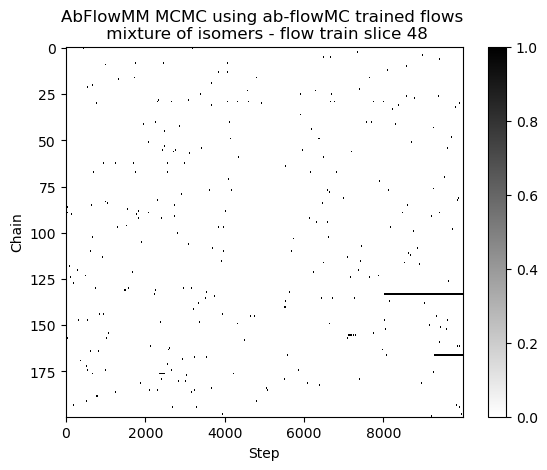

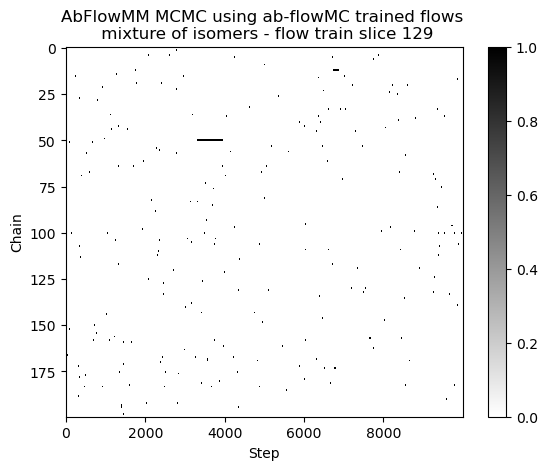

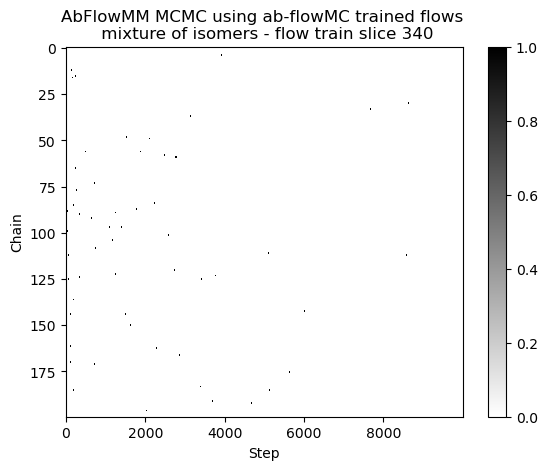

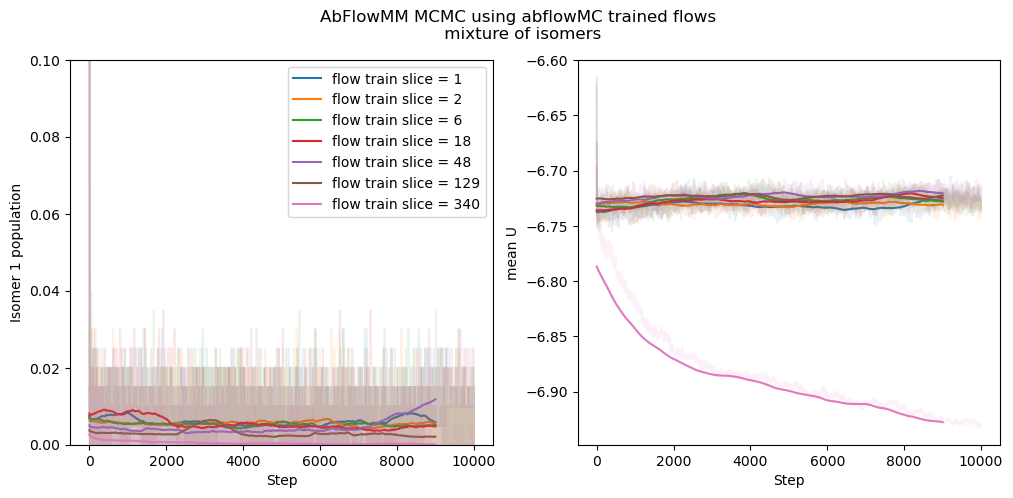

In [178]:
dic_results_mixture = {
    'kind': [],
    # 'isomer_id': [],
    # 'md_training_size': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'pop_isomer_1': [],
    'trial': [],
    'sample_size': [],
    'burn_in': [],
}

seed = 0
torch.manual_seed(seed)
kind = 'ab-flowMC'
process_id_mlps = process_ids_wNP
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int) # upo to 341
mlp_train_slices = [30] #[0]
burn_in =  1000
n_trial = 10

# mlp_models = []
# for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
#     mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[mlp_train_slice]
#     mlp_models.append(mlp_model)


for mlp_train_slice in mlp_train_slices:

    filename = '2023-12-12-ab-flows-mixture-wNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
    dic_mcmcs = load_pickle_file(filename, path=subproject_path + '/9-mcmc-bar/')

    plt.figure(figsize=(12, 5))
    plt.suptitle('AbFlowMM MCMC using abflowMC trained flows \n mixture of isomers')
    ax1 = plt.subplot(121)
    plt.sca(ax1)
    plt.xlabel('Step')
    plt.ylabel('Isomer 1 population')

    ax2 = plt.subplot(122)
    plt.sca(ax2)
    plt.xlabel('Step')
    plt.ylabel('mean U')

    
    for flow_train_slice in flow_train_slices:

        # flow_models = []
        # for isomer_id in mode_labels:
        #     df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
        #     process_id_flow = df_isomer['process_id'][0]
            
        #     flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]
        #     flow_models.append(flow_model)

        key = 'flow_train_slice_{:d}_mlp_train_slice_{:d}'.format(flow_train_slice, mlp_train_slice)
        mcmc_dic = dic_mcmcs[key]
        mc_samples = mcmc_dic['xs']
        is_samples = mcmc_dic['isomers']
        
        plt.sca(ax1)
        is_1_pop = is_samples.mean(dim=1)
        _ = plt.plot(is_1_pop, alpha=0.1)
        plt.plot(moving_average(is_1_pop, 1000), c=_[-1].get_color(), label='flow train slice = {:d}'.format(flow_train_slice))

        plt.sca(ax2)
        u = mcmc_dic['us'].mean(dim=1)
        plt.plot(u, alpha=0.1)
        plt.plot(moving_average(u, 1000), c=_[-1].get_color())

        plt.figure()
        plt.title('AbFlowMM MCMC using ab-flowMC trained flows \n mixture of isomers - flow train slice {:d}'.format( flow_train_slice))
        plt.imshow(is_samples.numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
        plt.colorbar()
        plt.xlabel('Step')
        plt.ylabel('Chain')

        n_chains = mc_samples.shape[1]
        n_chain_per_trial = n_chains // n_trial
        print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))

        for trial in range(n_trial):
            is_samples_t = is_samples[burn_in:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial]
            pop_isomer_1 = is_samples_t.mean().item()

            dic_results_mixture['kind'].append(kind)
            # dic_results_mixture['isomer_id'].append(isomer_id)
            # dic_results_mixture['md_training_size'].append(md_training_size)
            dic_results_mixture['process_id_flow'].append(process_id_flow)
            dic_results_mixture['flow_train_slice'].append(flow_train_slice)
            dic_results_mixture['mc seed'].append(seed)
            dic_results_mixture['pop_isomer_1'].append(pop_isomer_1)
            dic_results_mixture['trial'].append(trial)
            dic_results_mixture['sample_size'].append(is_samples_t.flatten().shape[0])
            print(is_samples_t.flatten().shape[0])
            dic_results_mixture['mlp_train_slice'].append(mlp_train_slice)
            dic_results_mixture['burn_in'].append(burn_in)

    plt.sca(ax1)
    plt.legend()
    plt.ylim(0, 0.1)

In [179]:
date = str(today)
df = pd.DataFrame(dic_results_mixture)
df.to_csv(subproject_path + '/9-mcmc-bar/' + date + '-abmc-flows-mixture-wNP-results-mlpmodel{:d}.csv'.format(mlp_train_slice))
df

,kind,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,pop_isomer_1,trial,sample_size,burn_in
0,ab-flowMC,28685741,1,30,0,0.006200,0,180000,1000
1,ab-flowMC,28685741,1,30,0,0.004817,1,180000,1000
2,ab-flowMC,28685741,1,30,0,0.005756,2,180000,1000
3,ab-flowMC,28685741,1,30,0,0.005133,3,180000,1000
4,ab-flowMC,28685741,1,30,0,0.005372,4,180000,1000
...,...,...,...,...,...,...,...,...,...
65,ab-flowMC,28685741,340,30,0,0.000428,5,180000,1000
66,ab-flowMC,28685741,340,30,0,0.000311,6,180000,1000
67,ab-flowMC,28685741,340,30,0,0.000417,7,180000,1000
68,ab-flowMC,28685741,340,30,0,0.000350,8,180000,1000


### 2.z.2 Adaptive 100% DFT flows - "woNP"

Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000
Total number of chains per trial = 20 and samples per trial = 200000
180000
180000
180000
180000
180000
180000
180000
180000
180000
180000


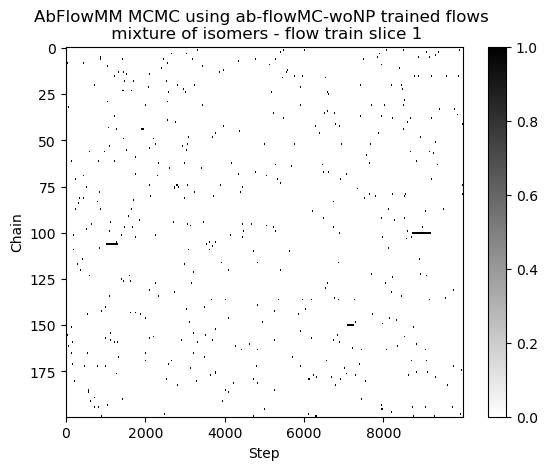

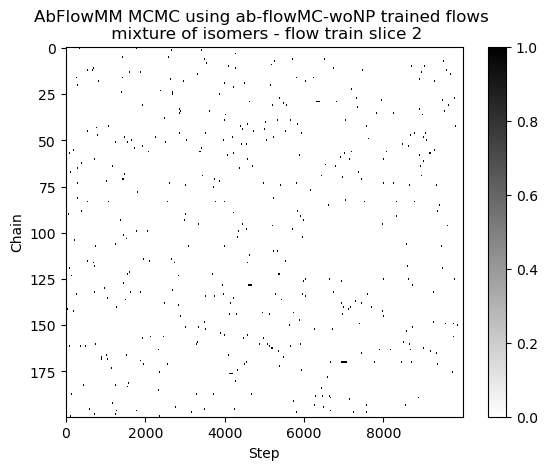

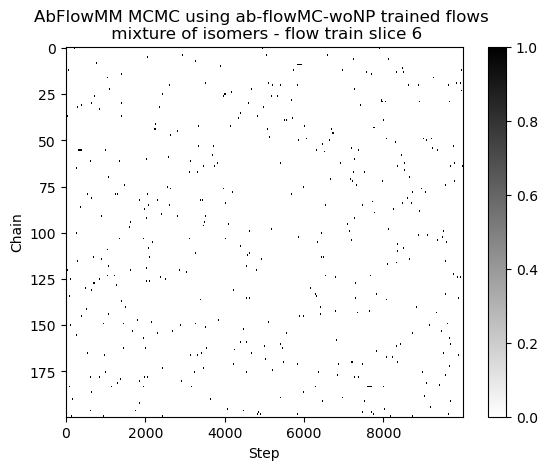

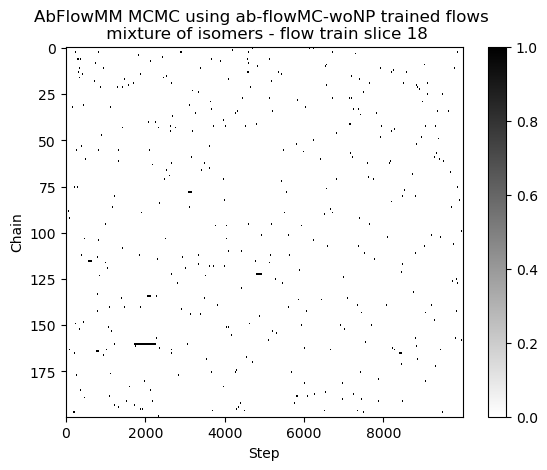

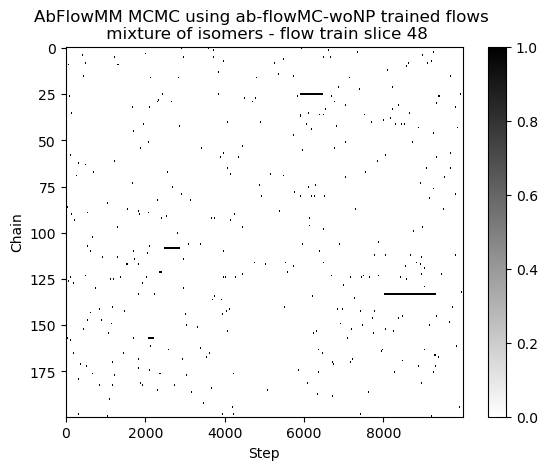

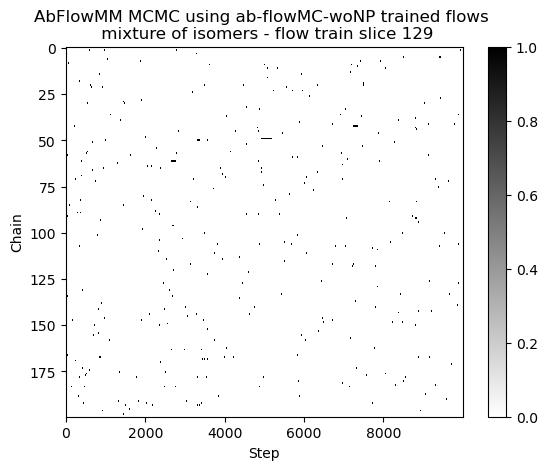

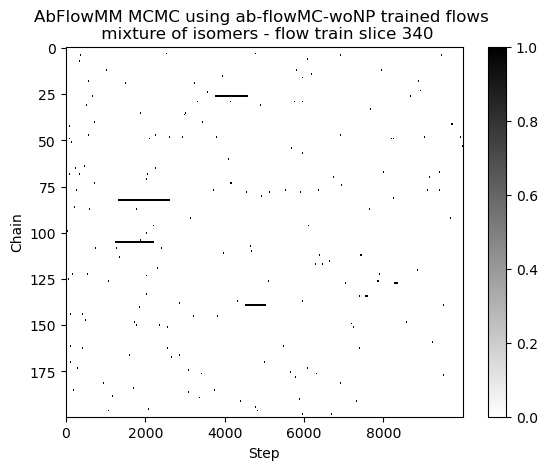

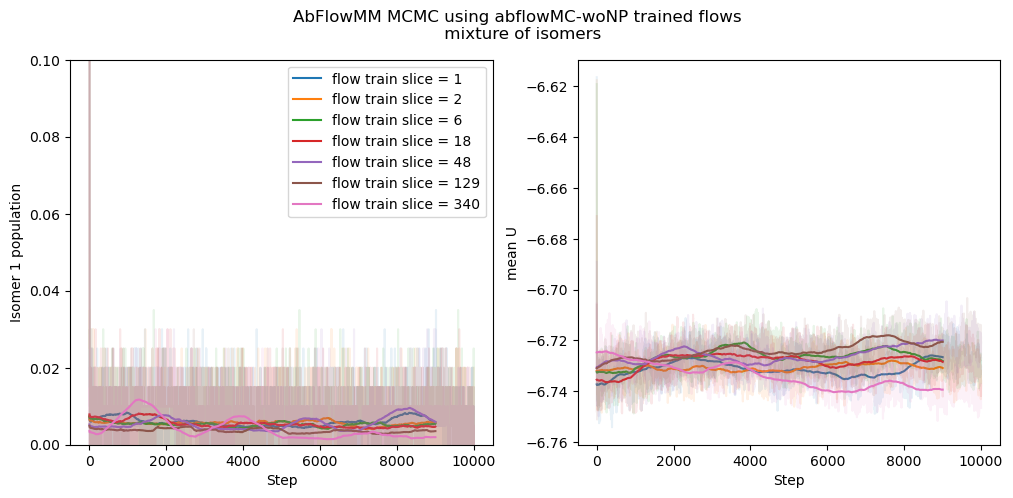

In [186]:
dic_results_mixture = {
    'kind': [],
    # 'isomer_id': [],
    # 'md_training_size': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'pop_isomer_1': [],
    'trial': [],
    'sample_size': [],
    'burn_in': [],
}

seed = 0
torch.manual_seed(seed)
kind = 'ab-flowMC-woNP'
process_id_mlps = process_ids_wNP
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int) # upo to 341
mlp_train_slices = [30] #[0]
burn_in =  1000
n_trial = 10

# mlp_models = []
# for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
#     mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[mlp_train_slice]
#     mlp_models.append(mlp_model)


for mlp_train_slice in mlp_train_slices:

    filename = '2023-12-12-ab-flows-mixture-woNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
    dic_mcmcs = load_pickle_file(filename, path=subproject_path + '/9-mcmc-bar/')

    plt.figure(figsize=(12, 5))
    plt.suptitle('AbFlowMM MCMC using abflowMC-woNP trained flows \n mixture of isomers')
    ax1 = plt.subplot(121)
    plt.sca(ax1)
    plt.xlabel('Step')
    plt.ylabel('Isomer 1 population')

    ax2 = plt.subplot(122)
    plt.sca(ax2)
    plt.xlabel('Step')
    plt.ylabel('mean U')

    
    for flow_train_slice in flow_train_slices:

        # flow_models = []
        # for isomer_id in mode_labels:
        #     df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
        #     process_id_flow = df_isomer['process_id'][0]
            
        #     flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]
        #     flow_models.append(flow_model)

        key = 'flow_train_slice_{:d}_mlp_train_slice_{:d}'.format(flow_train_slice, mlp_train_slice)
        mcmc_dic = dic_mcmcs[key]
        mc_samples = mcmc_dic['xs']
        is_samples = mcmc_dic['isomers']
        
        plt.sca(ax1)
        is_1_pop = is_samples.mean(dim=1)
        _ = plt.plot(is_1_pop, alpha=0.1)
        plt.plot(moving_average(is_1_pop, 1000), c=_[-1].get_color(), label='flow train slice = {:d}'.format(flow_train_slice))

        plt.sca(ax2)
        u = mcmc_dic['us'].mean(dim=1)
        plt.plot(u, alpha=0.1)
        plt.plot(moving_average(u, 1000), c=_[-1].get_color())

        plt.figure()
        plt.title('AbFlowMM MCMC using ab-flowMC-woNP trained flows \n mixture of isomers - flow train slice {:d}'.format( flow_train_slice))
        plt.imshow(is_samples.numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
        plt.colorbar()
        plt.xlabel('Step')
        plt.ylabel('Chain')

        n_chains = mc_samples.shape[1]
        n_chain_per_trial = n_chains // n_trial
        print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))

        for trial in range(n_trial):
            is_samples_t = is_samples[burn_in:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial]
            pop_isomer_1 = is_samples_t.mean().item()

            dic_results_mixture['kind'].append(kind)
            # dic_results_mixture['isomer_id'].append(isomer_id)
            # dic_results_mixture['md_training_size'].append(md_training_size)
            dic_results_mixture['process_id_flow'].append(process_id_flow)
            dic_results_mixture['flow_train_slice'].append(flow_train_slice)
            dic_results_mixture['mc seed'].append(seed)
            dic_results_mixture['pop_isomer_1'].append(pop_isomer_1)
            dic_results_mixture['trial'].append(trial)
            dic_results_mixture['sample_size'].append(is_samples_t.flatten().shape[0])
            print(is_samples_t.flatten().shape[0])
            dic_results_mixture['mlp_train_slice'].append(mlp_train_slice)
            dic_results_mixture['burn_in'].append(burn_in)

    plt.sca(ax1)
    plt.legend()
    plt.ylim(0, 0.1)

In [187]:
date = str(today)
df = pd.DataFrame(dic_results_mixture)
df.to_csv(subproject_path + '/9-mcmc-bar/' + date + '-abmc-flows-mixture-woNP-results-mlpmodel{:d}.csv'.format(mlp_train_slice))
df

,kind,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,pop_isomer_1,trial,sample_size,burn_in
0,ab-flowMC-woNP,28685741,1,30,0,0.006194,0,180000,1000
1,ab-flowMC-woNP,28685741,1,30,0,0.004850,1,180000,1000
2,ab-flowMC-woNP,28685741,1,30,0,0.005667,2,180000,1000
3,ab-flowMC-woNP,28685741,1,30,0,0.005222,3,180000,1000
4,ab-flowMC-woNP,28685741,1,30,0,0.005272,4,180000,1000
...,...,...,...,...,...,...,...,...,...
65,ab-flowMC-woNP,28685741,340,30,0,0.007650,5,180000,1000
66,ab-flowMC-woNP,28685741,340,30,0,0.006300,6,180000,1000
67,ab-flowMC-woNP,28685741,340,30,0,0.001517,7,180000,1000
68,ab-flowMC-woNP,28685741,340,30,0,0.001717,8,180000,1000


### 2.z.3 Combining wNP and woNP

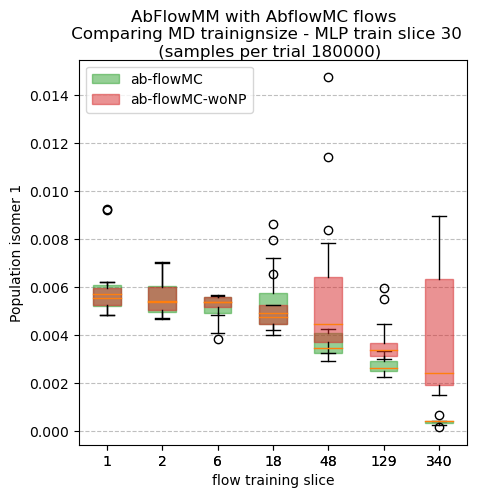

In [188]:
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
sample_size = 180000	
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int) # upo to 341

plt.figure(figsize=(5, 5))
handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
ax = plt.subplot(111)
plt.suptitle('AbFlowMM with AbflowMC flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

kinds = ['ab-flowMC', 'ab-flowMC-woNP']

color_key = 2
for kind, filekey in zip(kinds, ['wNP', 'woNP']):

    filename = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-mixture-{:s}-results-mlpmodel{:d}'.format(filekey, mlp_train_slice)
    df = pd.read_csv(filename + '.csv') 

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == kind]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
    
    
    plt.sca(ax)
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(color_key), color = "C{:d}".format(color_key), alpha=0.5),
                )
    red_patch = mpatches.Patch(color = "C{:d}".format(color_key), alpha=0.5, label=kind)
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')

    color_key += 1


plt.legend(handles=handles)


# 3 - back to deepBAR - using the MLP model trained adaptively to power the MCMC & the free energy estimator

## 3.1 Runing and saving single isomers MCMC

### 3.1.1 Adaptive 30% DFT Flows - "wNP"

In [146]:
np.logspace(0, np.log(341)/np.log(10), 8).astype(int)

array([  1,   2,   5,  12,  28,  64, 148, 340])

In [157]:
process_id_mlps = process_ids_wNP
process_id_flows = process_ids_wNP
folder = '/2-adaptive-mlp/'

seed = 0
torch.manual_seed(seed)

# flow_train_slices = [0, 3, 6, 9, 12]  # upon 341
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)

dic_mcmcs_abmc_flows = {}


# MH parameters
n_chains = 200
mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'
n_steps = 10000
mlp_train_slice = 30 # ,0


### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models


### Running the MCMC for the selected training slices
for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
    mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
    flow_model = flow_models_all['isomer {:d}'.format(isomer_id)][flow_train_slice]

    for flow_train_slice in flow_train_slices:
        flow_model = flow_models[flow_train_slice]
        init = flow_model.sample(n_chains)
        init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
    

        to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                            temperature,
                            mixture,
                            mlp_models=[mlp_model],
                            frac_computed=0.2,
                            dim=12,
                            update_weights=update_weights,
                            scheduler_weights=10,
                            alpha=0.5,
                            return_ratios=True,
                            return_proposals=True,
                            with_tqdm=True,
                            device='cpu',
                            folder_name=None,
                        )
        key = 'isomer_{:d}_flow_train_slice_{:d}'.format(isomer_id, flow_train_slice)
        dic_mcmcs_abmc_flows[key] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.020: 100%|██████████| 10000/10000 [01:12<00:00, 137.62it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.015: 100%|██████████| 10000/10000 [01:11<00:00, 139.84it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


...

Step 9999 	 Acceptance Rate 0.360: 100%|██████████| 10000/10000 [01:06<00:00, 150.25it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.400: 100%|██████████| 10000/10000 [01:07<00:00, 147.29it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.355: 100%|██████████| 10000/10000 [01:08<00:00, 146.70it/s]


In [154]:
# #Concatenate results before saving
# dic_mcmcs_abmc_flows.keys()
# dic_mcmcs_abmc_flows_old = load_pickle_file('2023-12-05-Ab-flows-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice), path=subproject_path + '9-mcmc-bar/')

# dic_combined = {}
# for key in dic_mcmcs_abmc_flows.keys():
#     dic_combined[key] = dic_mcmcs_abmc_flows[key]
# for key in dic_mcmcs_abmc_flows_old.keys():
#     dic_combined[key] = dic_mcmcs_abmc_flows_old[key]

In [158]:
# save the results
date = str(today)
filename = subproject_path + '/9-mcmc-bar/'+ date + '-ab-flows-wNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
with open(filename, 'wb') as f:
    pickle.dump(dic_mcmcs_abmc_flows, f)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-ab-flows-wNP-MCMC-outputs-mlpmodel30.pkl


### 3.1.2 Adaptive 100% DFT Flows - "woNP"

In [155]:
process_id_mlps = process_ids_wNP
folder_mlp = '/2-adaptive-mlp/'
process_id_flows = process_ids_woNP
folder = '/1-adaptive/'

seed = 0
torch.manual_seed(seed)

# flow_train_slices = [0, 3, 6, 9, 12]  # upon 341
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)

dic_mcmcs_abmc_flows = {}


# MH parameters
n_chains = 200
mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'
n_steps = 10000
mlp_train_slice = 30 # ,0


### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder_mlp)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models


### Running the MCMC for the selected training slices
for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):
    mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
    flow_model = flow_models_all['isomer {:d}'.format(isomer_id)][flow_train_slice]

    for flow_train_slice in flow_train_slices:
        flow_model = flow_models[flow_train_slice]
        init = flow_model.sample(n_chains)
        init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
    

        to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                            temperature,
                            mixture,
                            mlp_models=[mlp_model],
                            frac_computed=0.2,
                            dim=12,
                            update_weights=update_weights,
                            scheduler_weights=10,
                            alpha=0.5,
                            return_ratios=True,
                            return_proposals=True,
                            with_tqdm=True,
                            device='cpu',
                            folder_name=None,
                        )
        key = 'isomer_{:d}_flow_train_slice_{:d}'.format(isomer_id, flow_train_slice)
        dic_mcmcs_abmc_flows[key] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.020: 100%|██████████| 10000/10000 [01:06<00:00, 150.53it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.015: 100%|██████████| 10000/10000 [01:06<00:00, 149.46it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


...

Step 9999 	 Acceptance Rate 0.410: 100%|██████████| 10000/10000 [01:04<00:00, 153.85it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.440: 100%|██████████| 10000/10000 [01:05<00:00, 152.20it/s]


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.430: 100%|██████████| 10000/10000 [01:06<00:00, 151.45it/s]


In [156]:
# save the results
date = str(today)
filename = subproject_path + '/9-mcmc-bar/'+ date + '-ab-flows-woNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice)
with open(filename, 'wb') as f:
    pickle.dump(dic_mcmcs_abmc_flows, f)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-ab-flows-woNP-MCMC-outputs-mlpmodel30.pkl


## 3.2 - Computing Deep BAR

### 3.2.1 - Adaptive 30% DFT Flows - "wNP"

In [160]:
dic_results_bar_abmc_flows = {
    'kind': [],
    'isomer_id': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'log_r': [],
    'trial': [],
    'sample_size': [],
}

seed = 0
torch.manual_seed(seed)
flow_training_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)
mlp_train_slices = [30] #[0]

process_id_mlps = process_ids_wNP
folder_mlp = '/2-adaptive-mlp/'

process_id_flows = process_ids_wNP
folder = '/2-adaptive-mlp/'


### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder_mlp)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models


for mlp_train_slice in mlp_train_slices:

    dic_mcmcs_abmc_flows = load_pickle_file('2023-12-12-ab-flows-wNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice), path=subproject_path + '/9-mcmc-bar/')

    for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):

        mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
        flow_models = flow_models_all['isomer {:d}'.format(isomer_id)]

        for flow_train_slice in flow_training_slices:
            key = 'isomer_{:d}_flow_train_slice_{:d}'.format(isomer_id, flow_train_slice)
            mcmc_dic = dic_mcmcs_abmc_flows[key]
            mc_samples = mcmc_dic['xs']
            
            flow_model = flow_models[flow_train_slice]

            prop = flow_model
            target_u = mlp_model

            n_trial = 10
            n_chains = mc_samples.shape[1]
            n_chain_per_trial = n_chains // n_trial
            print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
            log_ratio_0_BARs = []
            log_err_0_BARs = []

            for trial in range(n_trial):
                mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
                prop_samples_t = prop.sample(mc_samples_t.shape[0])
                logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
                logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
                logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
                logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


                logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                            maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                log_ratio_0_BARs.append(logr)
                log_err_0_BARs.append(logr_err)

                dic_results_bar_abmc_flows['kind'].append('ab-flowMC')
                dic_results_bar_abmc_flows['isomer_id'].append(isomer_id)
                dic_results_bar_abmc_flows['process_id_flow'].append(process_id_flow)
                dic_results_bar_abmc_flows['flow_train_slice'].append(flow_train_slice)
                dic_results_bar_abmc_flows['mc seed'].append(seed)
                dic_results_bar_abmc_flows['log_r'].append(logr)
                dic_results_bar_abmc_flows['trial'].append(trial)
                dic_results_bar_abmc_flows['sample_size'].append(mc_samples_t.shape[0])
                dic_results_bar_abmc_flows['mlp_train_slice'].append(mlp_train_slice)

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.01387319470814e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.638713195641685e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -8.718945991859073e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.788212692119487e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0079052401579247e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.4195782114256872e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.779692098580199e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.7092420964436315e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 7.703933789571238e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.0666340958541696e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/

Total number of chains per trial = 20 and samples per trial = 200000


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.669845858032204e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.517108785265009e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.565519307358045e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.818240429609432e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.8626126606923208e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/ana

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.771125986735569e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.876371269167066e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.536527159070829e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1938836337321845e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.529543660846684e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 9.540025587284617e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.914328746328465e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.2341754995759402e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.779623822059875e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.8763429043010547e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/

In [161]:
df = pd.DataFrame(dic_results_bar_abmc_flows)
df

,kind,isomer_id,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,log_r,trial,sample_size
0,ab-flowMC,0,28707820,1,30,0,-212.312773,0,200000
1,ab-flowMC,0,28707820,1,30,0,-212.314891,1,200000
2,ab-flowMC,0,28707820,1,30,0,-212.366326,2,200000
3,ab-flowMC,0,28707820,1,30,0,-212.354706,3,200000
4,ab-flowMC,0,28707820,1,30,0,-212.301330,4,200000
...,...,...,...,...,...,...,...,...,...
135,ab-flowMC,1,28707820,340,30,0,-208.191465,5,200000
136,ab-flowMC,1,28707820,340,30,0,-208.268349,6,200000
137,ab-flowMC,1,28707820,340,30,0,-208.404069,7,200000
138,ab-flowMC,1,28707820,340,30,0,-208.220478,8,200000


In [163]:
df = pd.DataFrame(dic_results_bar_abmc_flows)
filename = subproject_path + '/9-mcmc-bar/'+ str(today) + '-abmc-flows-wNP-BAR-results-mlpmodel{:d}.csv'.format(mlp_train_slice)
df.to_csv(filename, index=False)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-abmc-flows-wNP-BAR-results-mlpmodel30.csv


### 3.2.2 - Adaptive 100% DFT Flows - "woNP"

In [166]:
dic_results_bar_abmc_flows = {
    'kind': [],
    'isomer_id': [],
    'process_id_flow': [],
    'flow_train_slice': [],
    'mlp_train_slice': [],
    'mc seed': [],
    'log_r': [],
    'trial': [],
    'sample_size': [],
}

seed = 0
torch.manual_seed(seed)
flow_training_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)
mlp_train_slices = [30] #[0]

process_id_mlps = process_ids_wNP
folder_mlp = '/2-adaptive-mlp/'

process_id_flows = process_ids_woNP
folder = '/1-adaptive/'


### Loading all the models
mlp_models_all = {}
flow_models_all = {}
for isomer_id, process_id_mlp, process_id_flow in zip(mode_labels, process_id_mlps, process_id_flows):
    key_isomer = 'isomer {:d}'.format(isomer_id)

    mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + folder_mlp)
    mlp_models_all[key_isomer] = mlp_models

    flow_models = load_models(isomer_id, process_id_flow, project_path=subproject_path + folder)
    flow_models_all[key_isomer] = flow_models


for mlp_train_slice in mlp_train_slices:

    dic_mcmcs_abmc_flows = load_pickle_file('2023-12-12-ab-flows-woNP-MCMC-outputs-mlpmodel{:d}.pkl'.format(mlp_train_slice), path=subproject_path + '/9-mcmc-bar/')

    for isomer_id, process_id_mlp in zip(mode_labels, process_id_mlps):

        mlp_model = mlp_models_all['isomer {:d}'.format(isomer_id)][mlp_train_slice]
        flow_models = flow_models_all['isomer {:d}'.format(isomer_id)]

        for flow_train_slice in flow_training_slices:
            key = 'isomer_{:d}_flow_train_slice_{:d}'.format(isomer_id, flow_train_slice)
            mcmc_dic = dic_mcmcs_abmc_flows[key]
            mc_samples = mcmc_dic['xs']
            
            flow_model = flow_models[flow_train_slice]

            prop = flow_model
            target_u = mlp_model

            n_trial = 10
            n_chains = mc_samples.shape[1]
            n_chain_per_trial = n_chains // n_trial
            print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
            log_ratio_0_BARs = []
            log_err_0_BARs = []

            for trial in range(n_trial):
                mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
                prop_samples_t = prop.sample(mc_samples_t.shape[0])
                logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
                logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
                logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
                logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


                logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                            maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                log_ratio_0_BARs.append(logr)
                log_err_0_BARs.append(logr_err)

                dic_results_bar_abmc_flows['kind'].append('ab-flowMC')
                dic_results_bar_abmc_flows['isomer_id'].append(isomer_id)
                dic_results_bar_abmc_flows['process_id_flow'].append(process_id_flow)
                dic_results_bar_abmc_flows['flow_train_slice'].append(flow_train_slice)
                dic_results_bar_abmc_flows['mc seed'].append(seed)
                dic_results_bar_abmc_flows['log_r'].append(logr)
                dic_results_bar_abmc_flows['trial'].append(trial)
                dic_results_bar_abmc_flows['sample_size'].append(mc_samples_t.shape[0])
                dic_results_bar_abmc_flows['mlp_train_slice'].append(mlp_train_slice)

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.0077907524628245e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -7.888192214977607e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.904491279627109e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -7.577508824851975e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.7710478346089076e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.658435332454246e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.853888526668015e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.401221440910376e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.7484465426350653e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.535562626666433e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/

Total number of chains per trial = 20 and samples per trial = 200000


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.5958150331462093e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.330869619981968e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.982944000810676e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.8896288029045536e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.54646083073385e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.531181603961159e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.0623075701896596e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.9931717904219113e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.9129169288589765e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 5.767657341948507e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.864204105890167e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 4.80659048207599e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0753569767985027e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.2457038798838767e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.9050203832193802e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

In [167]:
df = pd.DataFrame(dic_results_bar_abmc_flows)
filename = subproject_path + '/9-mcmc-bar/'+ str(today) + '-abmc-flows-woNP-BAR-results-mlpmodel{:d}.csv'.format(mlp_train_slice)
df.to_csv(filename, index=False)
print(filename)

/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/adaptive-350/earlier_simulations/9-mcmc-bar/2023-12-12-abmc-flows-woNP-BAR-results-mlpmodel30.csv


### 3.2.3 - Combined boxplot

In [190]:
filename_wNP = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-wNP-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
filename_woNP = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-woNP-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)

df_wNP = pd.read_csv(filename_wNP + '.csv')
df_woNP = pd.read_csv(filename_woNP + '.csv')

df_wNP['kind'] = 'ab-flowMC'
df_woNP['kind'] = 'ab-flowMC-woNP'

df = pd.concat([df_wNP, df_woNP])
df

# df_combined = pd.concat([df_old, df])

,kind,isomer_id,process_id_flow,flow_train_slice,mlp_train_slice,mc seed,log_r,trial,sample_size
0,ab-flowMC,0,28707820,1,30,0,-212.312773,0,200000
1,ab-flowMC,0,28707820,1,30,0,-212.314891,1,200000
2,ab-flowMC,0,28707820,1,30,0,-212.366326,2,200000
3,ab-flowMC,0,28707820,1,30,0,-212.354706,3,200000
4,ab-flowMC,0,28707820,1,30,0,-212.301330,4,200000
...,...,...,...,...,...,...,...,...,...
135,ab-flowMC-woNP,1,28685741,340,30,0,-208.353779,5,200000
136,ab-flowMC-woNP,1,28685741,340,30,0,-208.334702,6,200000
137,ab-flowMC-woNP,1,28685741,340,30,0,-208.552708,7,200000
138,ab-flowMC-woNP,1,28685741,340,30,0,-208.319079,8,200000


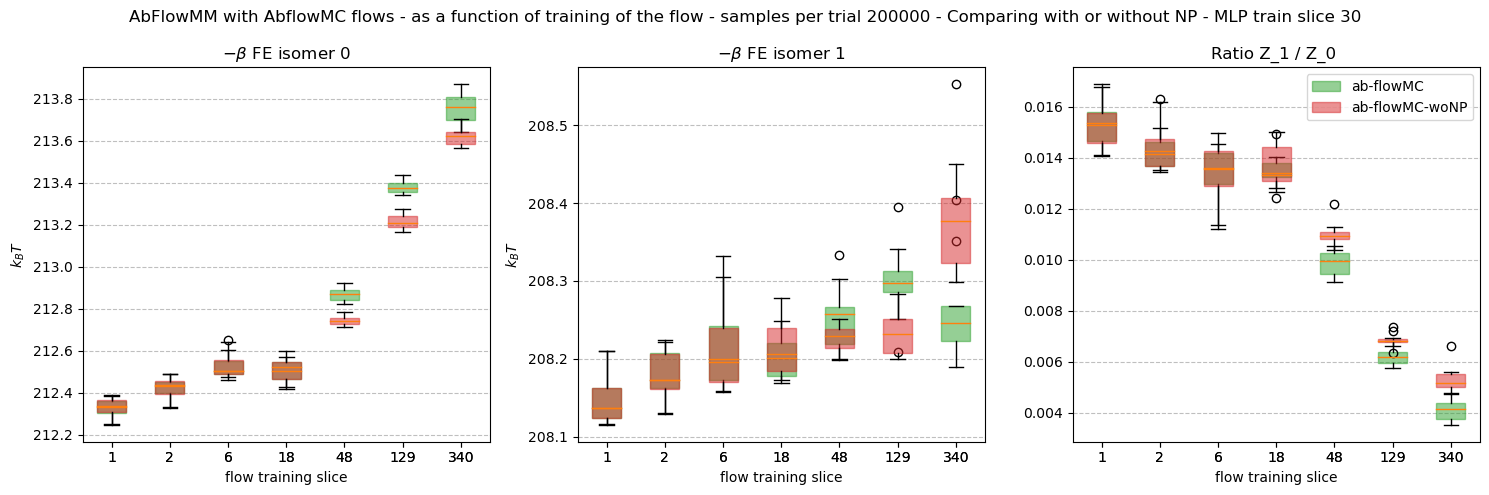

In [194]:
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

kinds = ['ab-flowMC', 'ab-flowMC-woNP']
sample_size = 200000
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing with or without NP - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for k,kind in enumerate(kinds):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == kind]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'$- \beta$ FE isomer 0'.format(sample_size))
    plt.boxplot(z0s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
                )
               
    plt.xlabel('flow training slice')
    plt.ylabel('$k_B T$')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.sca(axs[1])
    plt.title(r'$- \beta$ FE isomer 1'.format(sample_size))
    plt.boxplot(z1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    plt.ylabel('$k_B T$')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(k+2), alpha=0.5, label=kind)
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()

# 4 -  COMBINING BAR + FE on the same

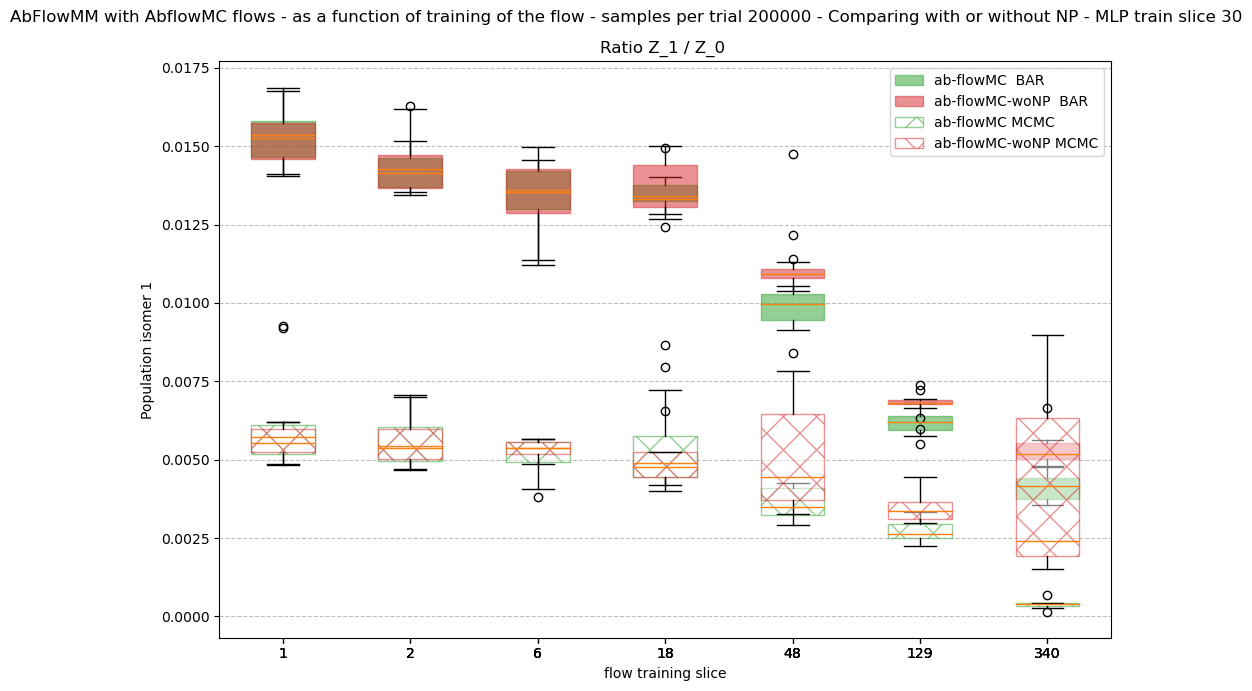

In [217]:
filename_wNP = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-wNP-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
filename_woNP = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-woNP-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)

df_wNP = pd.read_csv(filename_wNP + '.csv')
df_woNP = pd.read_csv(filename_woNP + '.csv')

df_wNP['kind'] = 'ab-flowMC'
df_woNP['kind'] = 'ab-flowMC-woNP'

df = pd.concat([df_wNP, df_woNP])
df

# plot boxplots of ratio of partition functions
mlp_train_slice = 30

kinds = ['ab-flowMC', 'ab-flowMC-woNP']
sample_size = 200000
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int)

plt.figure(figsize=(10, 7))
axs = [plt.subplot(111)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing with or without NP - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for k,kind in enumerate(kinds):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == kind]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    # plt.sca(axs[0])
    # plt.title(r'$- \beta$ FE isomer 0'.format(sample_size))
    # plt.boxplot(z0s, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
    #             )
               
    # plt.xlabel('flow training slice')
    # plt.ylabel('$k_B T$')
    # axs[0].set_axisbelow(True)
    # axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    # plt.sca(axs[1])
    # plt.title(r'$- \beta$ FE isomer 1'.format(sample_size))
    # plt.boxplot(z1s, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
    #             )
    # plt.xlabel('flow training slice')
    # plt.ylabel('$k_B T$')
    # axs[1].set_axisbelow(True)
    # axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    plt.sca(axs[0])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(k+2), color = "C{:d}".format(k+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(k+2), alpha=0.5, label=kind + "  BAR")
    handles.append(red_patch)



import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
sample_size = 180000	
flow_train_slices = np.logspace(0, np.log(341)/np.log(10), 7).astype(int) # upo to 341

# plt.figure(figsize=(5, 5))
# handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
# ax = plt.subplot(111)
# plt.suptitle('AbFlowMM with AbflowMC flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

kinds = ['ab-flowMC', 'ab-flowMC-woNP']

color_key = 2
for kind, filekey in zip(kinds, ['wNP', 'woNP']):

    filename = subproject_path + '/9-mcmc-bar/2023-12-12-abmc-flows-mixture-{:s}-results-mlpmodel{:d}'.format(filekey, mlp_train_slice)
    df = pd.read_csv(filename + '.csv') 

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == kind]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
    
    
    plt.sca(axs[0])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "w", color = "C{:d}".format(color_key), hatch = 'x', alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", edgecolor = "C{:d}".format(color_key), alpha=0.5, hatch = 'x', label=kind + " MCMC")
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')

    color_key += 1



plt.legend(handles=handles)
plt.tight_layout()



In [220]:
np.log(0.005)

-5.298317366548036

## OLD BELOW

## 3.1 - doing it for each isomer separately and combining

### 3.1.1 - MD flows

In [55]:
flow_train_slice = -1

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

df_args = dic_args['MD-training']
df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
# df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]
print(process_id_flow)

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]


process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_0 = to_return_md_flow


KeyError: 'MD-training'

In [54]:
process_id_flow

0    30019623
0    30007103
Name: process_id, dtype: int64

In [190]:
mc_samples = to_return_md_flow_isomer_0['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.066221585688254e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -8.983137433915545e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.441279920300076e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.08154372419267e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.4429462282805616e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/ana

In [191]:
seed = 42
seed = 0
torch.manual_seed(seed)
flow_train_slice = -1

isomer_id = 1
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
process_id_flow = df_isomer['process_id'][0]

flow_model = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[flow_train_slice]

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

# to_return_md_flow = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
#                     temperature,
#                     mixture,
#                     mlp_models=[mlp_model],
#                     frac_computed=0.2,
#                     dim=12,
#                     update_weights=update_weights,
#                     scheduler_weights=10,
#                     alpha=0.5,
#                     return_ratios=True,
#                     return_proposals=True,
#                     with_tqdm=True,
#                     device='cpu',
#                     folder_name=None,
#                  )

# to_return_md_flow_isomer_1 = to_return_md_flow


In [192]:
mc_samples = to_return_md_flow_isomer_1['xs']
prop = flow_model_md
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    print(mc_samples_t.shape, prop_samples_t.shape)
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)
    
    dic_results_all['kind'].append('MD')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000
torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.813443072431255e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.052849535833957e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


...

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.913551206049306e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.4402961186260654e-06 reached.
  warnings.warn(msg, RuntimeWarning)


torch.Size([200000, 12]) torch.Size([200000, 12])


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.8000235374747717e-06 reached.
  warnings.warn(msg, RuntimeWarning)


array([0.00445801, 0.00361745, 0.00570963, 0.00576201, 0.00580109,
       0.00578588, 0.00539244, 0.00639434, 0.00618031, 0.00518968])

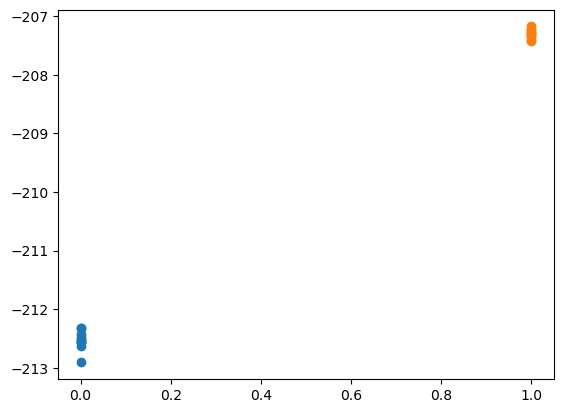

In [193]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

### 3.1.2 - AbFlowMC flows

In [249]:
# to_return_abflow_flow_isomer_0 = {}
# to_return_abflow_flow_isomer_1 = {}

In [250]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.190: 100%|██████████| 10000/10000 [01:19<00:00, 125.05it/s]


In [251]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.734594088200538e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.051756465310973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.276797770013218e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.2958616316136613e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0579815636901913e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

In [252]:
flow_train_slice = 0

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.350: 100%|██████████| 10000/10000 [01:20<00:00, 124.04it/s]


In [253]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)



Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -9.20969910112035e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9140110794069187e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1856887454086973e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 6.324223420506314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -5.463610364131455e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

array([0.00985862, 0.00497796, 0.00507602, 0.00940107, 0.00650915,
       0.00720697, 0.00513924, 0.01483733, 0.0080894 , 0.01203729])

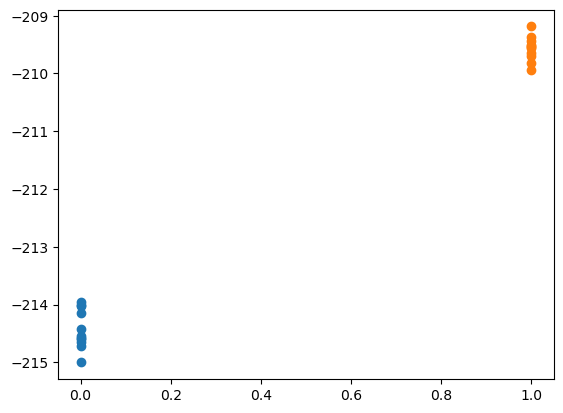

In [203]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

#### 3.1.2.2 Flow training slice 10

In [206]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 0
md_training_size = 4000

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_0[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.235: 100%|██████████| 10000/10000 [01:17<00:00, 129.18it/s]


In [207]:
mc_samples = to_return_abflow_flow_isomer_0[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_0_BARs.append(logr)
    log_err_0_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.5204953715274314e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.9066644938448007e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 7.617337729470819e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -6.676465062582793e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 9.439617372208886e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/a

In [208]:
flow_train_slice = 10

seed = 42
seed = 0
torch.manual_seed(seed)

isomer_id = 1
md_training_size = 4000

# process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_model = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[0]
flow_model = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[flow_train_slice]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 200

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_model(init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 10000

to_return = run_metropolis(flow_model, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=[mlp_model],
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

to_return_abflow_flow_isomer_1[flow_train_slice] = to_return


Running Metropolis-Hastings
Number of chains: 200
Number of steps: 10000
Temperature: 350.0K
Energy Type: mlp
Use Neural Predictor: True
Mixture Model: False


Step 9999 	 Acceptance Rate 0.310: 100%|██████████| 10000/10000 [01:17<00:00, 129.31it/s]


In [209]:
mc_samples = to_return_abflow_flow_isomer_1[flow_train_slice]['xs']
prop = flow_model
target_u = mlp_model

n_trial = 10
n_chains = mc_samples.shape[1]
n_chain_per_trial = n_chains // n_trial
print('Total number of chains per trial = {:d} and samples per trial = {:d}'.format(n_chain_per_trial, n_chain_per_trial * mc_samples.shape[0]))
log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(n_trial):
    mc_samples_t = mc_samples[:, trial*n_chain_per_trial:(trial+1)*n_chain_per_trial].reshape(-1, mc_samples.shape[-1])
    prop_samples_t = prop.sample(mc_samples_t.shape[0])
    logprob_prop = - prop.nll(prop_samples_t).detach().numpy() 
    logprob_mc = - prop.nll(mc_samples_t).detach().numpy() 
    logtgt_prop = - beta * target_u(prop_samples_t).detach().numpy()
    logtgt_mc = - beta * target_u(mc_samples_t).detach().numpy()


    logr, logr_err = compute_BAR_from_samples(logprob_prop, logprob_mc, logtgt_prop, logtgt_mc, 
                                maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
    log_ratio_1_BARs.append(logr)
    log_err_1_BARs.append(logr_err)

    dic_results_all['kind'].append('AbFlowMM')
    dic_results_all['isomer_id'].append(isomer_id)
    dic_results_all['md_training_size'].append(md_training_size)
    dic_results_all['process_id_flow'].append(process_id_flow)
    dic_results_all['flow_train_slice'].append(flow_train_slice)
    dic_results_all['mc seed'].append(seed)
    dic_results_all['log_r'].append(logr)
    dic_results_all['trial'].append(trial)


Total number of chains per trial = 20 and samples per trial = 200000


/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.641064727664343e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0589900227842008e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.6712616002223513e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.0588534848920972e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.5829195610403985e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou

array([0.00378317, 0.00406613, 0.00310225, 0.00337917, 0.00400396,
       0.00332852, 0.00350355, 0.00391103, 0.00382356, 0.00433757])

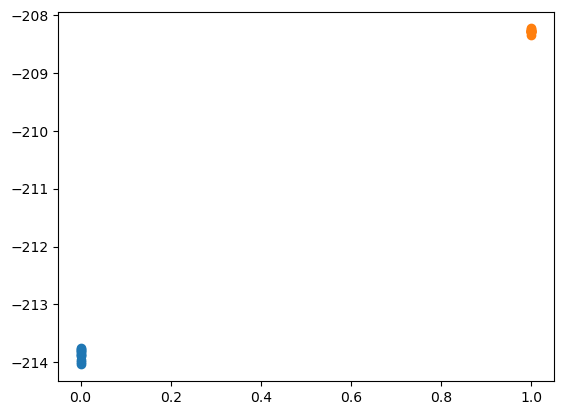

In [210]:
plt.scatter(0, np.mean(log_ratio_0_BARs), c='C0')
plt.scatter(0 * np.ones(len(log_err_0_BARs)), log_ratio_0_BARs)
plt.scatter(1, np.mean(log_ratio_1_BARs), c='C1')
plt.scatter(1 * np.ones(len(log_err_1_BARs)), log_ratio_1_BARs)

np.exp(np.array(log_ratio_0_BARs)- np.array(log_ratio_1_BARs))

# SAVING THE DATA

In [31]:
import datetime
today = datetime.date.today()
import pickle

In [33]:
# dic_mcmcs = {
#     'md_0': to_return_md_flow_isomer_0,
#     'abflow_0': to_return_abflow_flow_isomer_0,
#     'md_1': to_return_md_flow_isomer_1,
#     'abflow_1': to_return_abflow_flow_isomer_1
# }
# with open(subproject_path + '/'+str(today)+'-MCMC-outputs.pkl', 'wb') as f:
#     pickle.dump(dic_mcmcs, f)

# load
with open(subproject_path + '/2023-12-01-MCMC-outputs.pkl', 'rb') as f:
    dic_mcmcs = pickle.load(f)

In [36]:
# df = pd.DataFrame(dic_results_all)
# df.to_csv(subproject_path + '/'+str(today)+'-BAR-results.csv', index=False)




{'whiskers': [<matplotlib.lines.Line2D at 0x29ef76c10>,
 'caps': [<matplotlib.lines.Line2D at 0x293a67090>,
 'boxes': [<matplotlib.lines.Line2D at 0x293a64490>,
 'medians': [<matplotlib.lines.Line2D at 0x2959242d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x29ee4cc90>,
 'means': []}

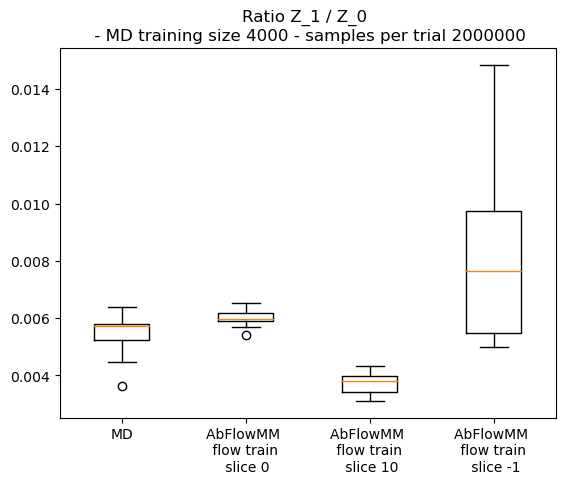

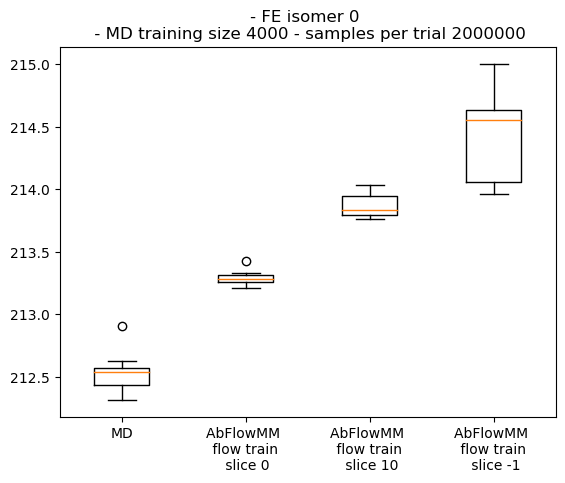

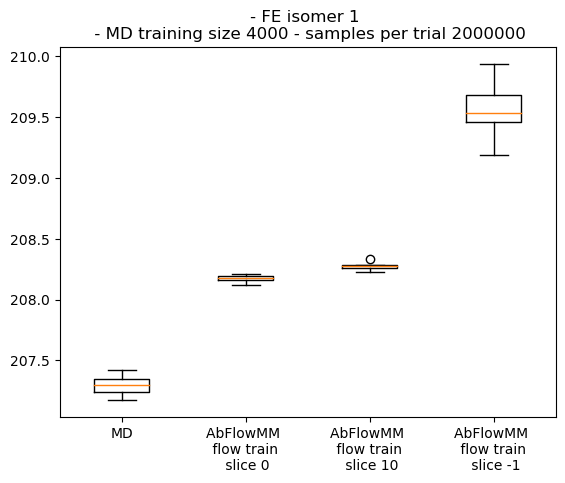

In [47]:
# plot boxplots of ratio of partition functions

df = pd.read_csv(subproject_path + '/2023-12-01-BAR-results.csv') 
n_chain_per_trial = 200
n_steps = 10000

zrs = []
z0s = []
z1s = []
labels = []

# MD results
labels.append('MD')
df_md = df.loc[df['kind'] == 'MD']
df_md_0 = df_md.loc[df_md['isomer_id'] == 0]
df_md_1 = df_md.loc[df_md['isomer_id'] == 1]

log_r_0 = df_md_0['log_r'].values
log_r_1 = df_md_1['log_r'].values

z_r_md = np.exp(log_r_0 - log_r_1)
zrs.append(z_r_md)

z_0_md = (-log_r_0)
z_1_md = (-log_r_1)
z0s.append(z_0_md)
z1s.append(z_1_md)

# AbFlowMM results - flow training slice -1
for train_slice in [0,10,-1]:
    labels.append('AbFlowMM \n flow train \n slice {:d}'.format(train_slice))
    df_abflow = df.loc[df['kind'] == 'AbFlowMM']
    df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0) & (df_abflow['flow_train_slice'] == train_slice)]
    df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1) & (df_abflow['flow_train_slice'] == train_slice)]

    log_r_0 = df_abflow_0['log_r'].values
    log_r_1 = df_abflow_1['log_r'].values

    z_r = np.exp(log_r_0 - log_r_1)
    zrs.append(z_r)

    z_0 = (-log_r_0)
    z_1 = (-log_r_1)
    z0s.append(z_0)
    z1s.append(z_1)



plt.figure()
plt.title('Ratio Z_1 / Z_0 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(zrs, labels=labels)

plt.figure()
plt.title('- FE isomer 0 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z0s, labels=labels)

plt.figure()
plt.title('- FE isomer 1 \n - MD training size {:d} - samples per trial {:d}'.format(md_training_size, n_chain_per_trial*n_steps))
plt.boxplot(z1s, labels=labels)
